# Brain Tumor MRI — Results: CNN vs Random Forest vs SVM

This notebook loads the **already-trained** models and test data (produced by
`data_preprocessing.py`, `train_cnn.py`, and `train_ml.py`) and generates the
comparison charts and metrics.

Run the three scripts first if you haven't:
```
python data_preprocessing.py
python train_cnn.py
python train_ml.py
```


## 1. Load models, test data, and imports

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_curve, auc,
)

sns.set_style("whitegrid")
%matplotlib inline

PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
with open(PROCESSED_DIR / "label_map.json") as f:
    label_map = json.load(f)
CLASSES = [label_map[str(i)] for i in range(len(label_map))]
NUM_CLASSES = len(CLASSES)

X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

cnn_model = tf.keras.models.load_model(MODELS_DIR / "cnn_model.h5")
rf_model = joblib.load(MODELS_DIR / "rf_model.joblib")
svm_model = joblib.load(MODELS_DIR / "svm_model.joblib")
hog_scaler = joblib.load(MODELS_DIR / "hog_scaler.joblib")  # SVM needs scaled HOG features

print(f"Test set: {X_test.shape}, classes: {CLASSES}")

Test set: (1600, 128, 128, 3), classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Get predictions from all three models

In [3]:
def extract_hog_features(X):
    features = []
    for img in X:
        gray = rgb2gray(img)
        feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm="L2-Hys")
        features.append(feat)
    return np.array(features)

# CNN predictions
# NOTE: the model already has a Rescaling(1./255) layer built in, so
# pass X_test in raw (0-255) — don't divide by 255 again here.
cnn_probs = cnn_model.predict(X_test)
cnn_preds = np.argmax(cnn_probs, axis=1)

# Random Forest predictions (needs HOG features, not raw pixels)
print("Extracting HOG features for test set...")
X_test_hog = extract_hog_features(X_test)
rf_preds = rf_model.predict(X_test_hog)
rf_probs = rf_model.predict_proba(X_test_hog)

# SVM predictions (needs the same scaled HOG features it was trained on)
# NOTE: SVM was trained with probability=False (much faster to train), so
# we use decision_function() instead of predict_proba() for ROC curves —
# roc_curve() works fine with raw decision scores, no calibration needed.
X_test_hog_scaled = hog_scaler.transform(X_test_hog)
svm_preds = svm_model.predict(X_test_hog_scaled)
svm_scores = svm_model.decision_function(X_test_hog_scaled)

print(f"CNN accuracy: {accuracy_score(y_test, cnn_preds):.4f}")
print(f"Random Forest accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"SVM accuracy: {accuracy_score(y_test, svm_preds):.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step
Extracting HOG features for test set...
CNN accuracy: 0.9313
Random Forest accuracy: 0.8375
SVM accuracy: 0.9075


## 3. Metrics table

In [4]:
def get_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {"model": name, "accuracy": acc, "precision_macro": precision,
            "recall_macro": recall, "f1_macro": f1}

cnn_metrics = get_metrics("CNN", y_test, cnn_preds)
rf_metrics = get_metrics("Random Forest", y_test, rf_preds)
svm_metrics = get_metrics("SVM", y_test, svm_preds)

comparison_df = pd.DataFrame([cnn_metrics, rf_metrics, svm_metrics])
comparison_df.to_csv(RESULTS_DIR / "comparison_report.csv", index=False)
comparison_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,CNN,0.93125,0.935508,0.93125,0.929412
1,Random Forest,0.83750,0.849989,0.83750,0.830744
2,SVM,0.90750,0.915438,0.90750,0.903881


In [5]:
print("=== CNN ===")
print(classification_report(y_test, cnn_preds, target_names=CLASSES, zero_division=0))
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=CLASSES, zero_division=0))
print("=== SVM ===")
print(classification_report(y_test, svm_preds, target_names=CLASSES, zero_division=0))

=== CNN ===
              precision    recall  f1-score   support

      glioma       0.99      0.78      0.87       400
  meningioma       0.91      0.95      0.93       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

=== Random Forest ===


              precision    recall  f1-score   support

      glioma       0.94      0.59      0.73       400
  meningioma       0.76      0.84      0.80       400
     notumor       0.81      1.00      0.89       400
   pituitary       0.89      0.93      0.91       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.83      1600
weighted avg       0.85      0.84      0.83      1600

=== SVM ===
              precision    recall  f1-score   support

      glioma       0.98      0.70      0.82       400
  meningioma       0.85      0.95      0.90       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.90      1600
weighted avg       0.92      0.91      0.90      1600



## 4. Confusion matrices

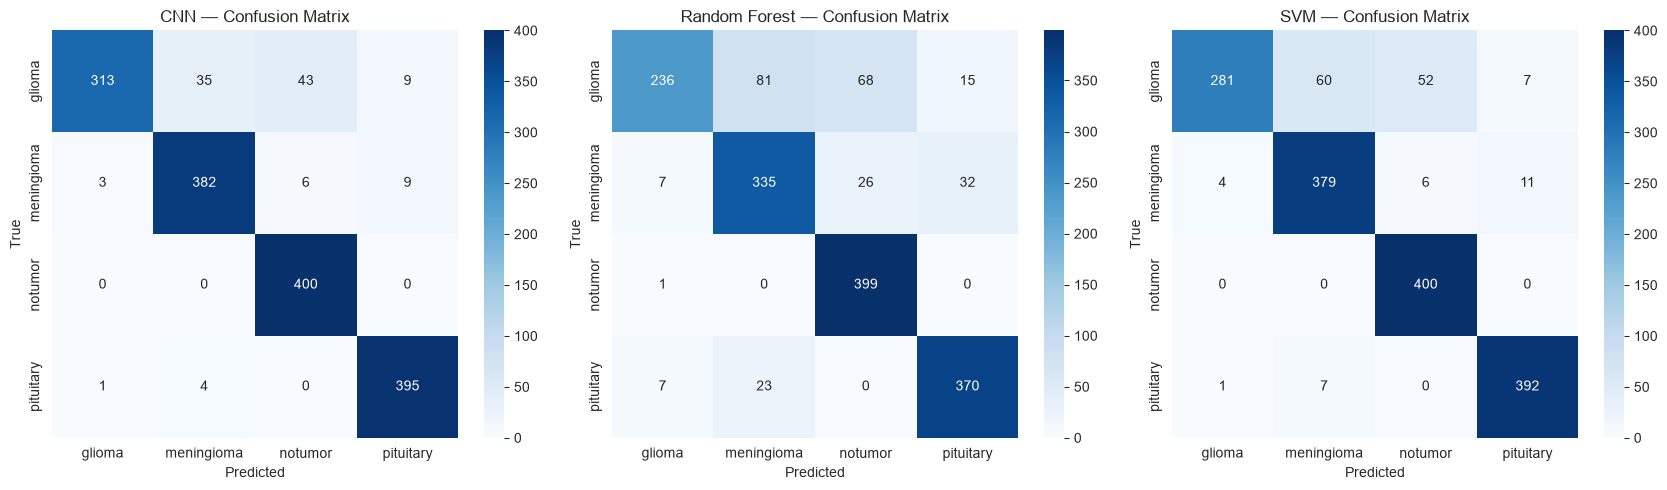

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, preds) in zip(axes, [("CNN", cnn_preds), ("Random Forest", rf_preds), ("SVM", svm_preds)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150)
plt.show()

## 5. ROC curves (one-vs-rest)

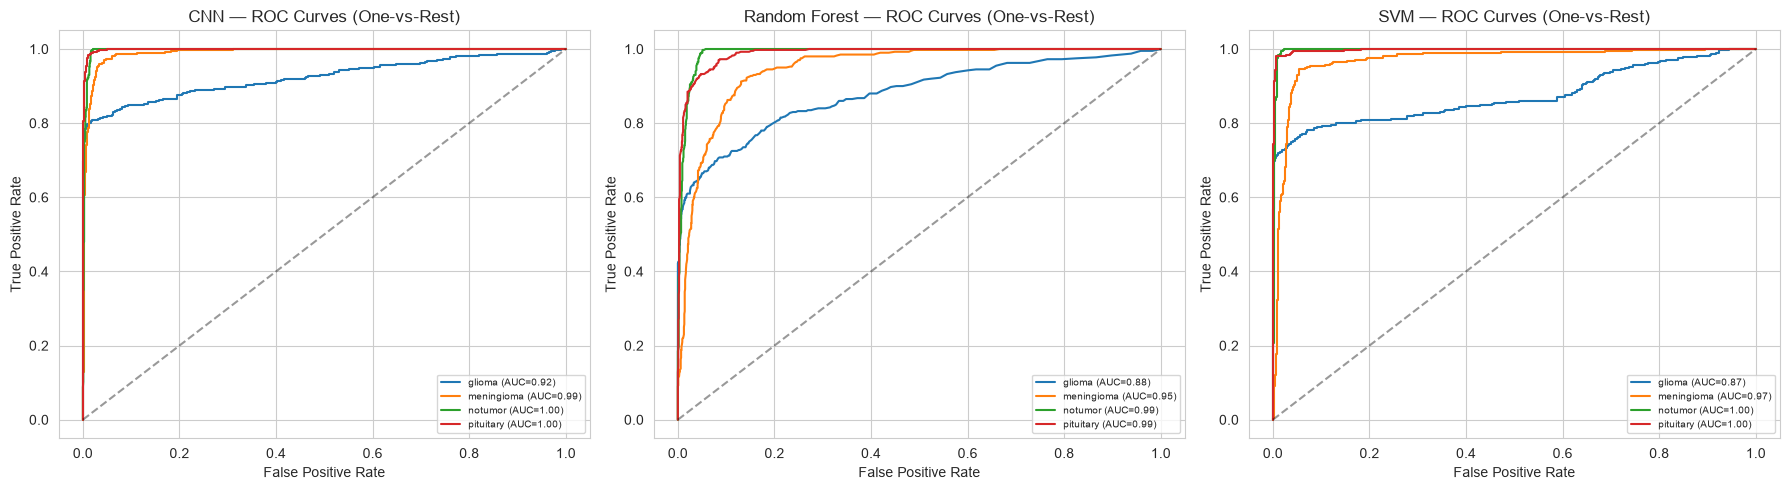

In [7]:
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, scores) in zip(axes, [("CNN", cnn_probs), ("Random Forest", rf_probs), ("SVM", svm_scores)]):
    for i, class_name in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"{name} — ROC Curves (One-vs-Rest)")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves.png", dpi=150)
plt.show()

## 6. Head-to-head comparison chart

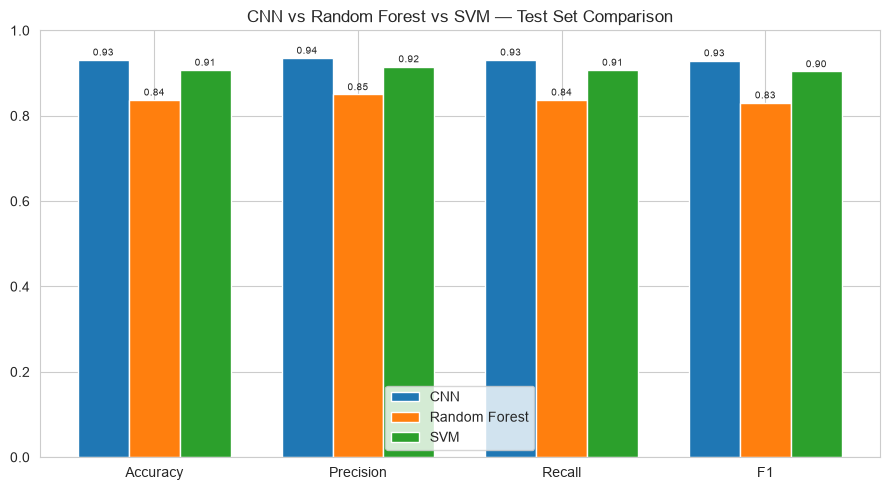

In [8]:
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, comparison_df.iloc[0][metrics_to_plot], width, label="CNN")
ax.bar(x, comparison_df.iloc[1][metrics_to_plot], width, label="Random Forest")
ax.bar(x + width, comparison_df.iloc[2][metrics_to_plot], width, label="SVM")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_title("CNN vs Random Forest vs SVM — Test Set Comparison")
ax.legend()
for i, metric in enumerate(metrics_to_plot):
    ax.text(i - width, comparison_df.iloc[0][metric] + 0.01, f"{comparison_df.iloc[0][metric]:.2f}", ha="center", fontsize=7)
    ax.text(i, comparison_df.iloc[1][metric] + 0.01, f"{comparison_df.iloc[1][metric]:.2f}", ha="center", fontsize=7)
    ax.text(i + width, comparison_df.iloc[2][metric] + 0.01, f"{comparison_df.iloc[2][metric]:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison_report.png", dpi=150)
plt.show()

## 7. Conclusion

Among the three models tested on 1,600 held-out MRI scans, the CNN performed
best (93.1% accuracy, 92.9% F1), followed by SVM (90.8% accuracy, 90.4% F1),
with Random Forest lowest (83.8% accuracy, 83.1% F1). This is expected: the
CNN learns features directly from pixels, while the two classical models rely
on hand-crafted HOG features, which capture less detail.

All three models classified "no tumor" perfectly, while glioma was the
hardest class to distinguish across all three — most often confused with
meningioma. This suggests glioma would benefit most from further improvement,
such as more training data or better feature extraction.

Overall, the CNN is the strongest choice for this task, with SVM as a solid,
lighter-weight alternative.